In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated,List,Optional,Any,Literal
from pydantic import Field
from langchain_core.messages import HumanMessage,SystemMessage,BaseMessage
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph.message import add_messages
import os

load_dotenv()

True

In [2]:
from langchain_cerebras import ChatCerebras

llm = ChatCerebras(
    model="qwen-3-235b-a22b-instruct-2507",
    api_key=os.getenv("CEREBRAS_API_KEY"),
    temperature=0.4,
)





# from langchain_ollama import ChatOllama

# llm = ChatOllama(model="mistral",temperature=0.8,max_tokens=100)

# response = llm.invoke("Say hello ,what is 2+2, what is the name if sunny leone")
# print(response.content)

c:\Users\ACER\OneDrive\Desktop\PYTHON\Langgraph\JawabAI\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from chromadb.utils import embedding_functions
import chromadb

# 1. INITIALIZE ONCE (Global Scope)
print("Loading embedding model into memory...")
embedding_function = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="all-MiniLM-L6-v2"
)
client = chromadb.PersistentClient(path="./chroma_db")
collection = client.get_or_create_collection(
    name="ticket_history",
)
print("Model and DB ready!")

Loading embedding model into memory...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2260.58it/s]


Model and DB ready!


In [4]:
class AgentState(TypedDict):
    # 1. Intake Data 
    ticket_id: str
    original_title: str
    original_description: str
    
    # 2. PII Redaction (Node 1) 
    redacted_title: Optional[str]
    redacted_description: Optional[str]
    
    # 3. Classification & Routing Logic (Node 2 & Routers) ---
    queue: Optional[str]
    ticket_type: Optional[str]
    priority: Optional[str]
    category: Optional[str] 
    confidence_score: Optional[float]
    is_repeated_issue: bool
    
    # 4. RAG & Automation Retrieval (Node 3B & 3C) 

    retrieved_contexts: List[str] 
    automation_suggestion: Optional[str]
    
    # 5. Generation (Node 4) 
    proposed_resolution: Optional[str]
    
    # 6. Validation / LLM-as-a-Judge (Node 5) 
    validation_passed: Optional[bool]
    validation_feedback: Optional[str] 
    
    # 7. Final Output & Logging (Node 6A/6B)
    final_status: Optional[str]  

In [5]:
class RedactionResult(TypedDict):
    redacted_title: str
    redacted_description: str


def redactPII(state:AgentState)->AgentState:
    
    # Redact PII from orignal title and description using llm
    print("Redacting PII from the ticket...")
    prompt=f"""You are a helpful assistant working for microsoft customer service ,for redacting personally identifiable information (PII) from IT support tickets.
        Given the following ticket details, please redact any PII while preserving the overall context and meaning of the ticket for accurate classification and resolution.
        Original Title: {state['original_title']}
        Original Description: {state['original_description']} """
    format_llm=llm.with_structured_output(RedactionResult)
    response=format_llm.invoke(prompt)
    #return {'redacted_title':'NO','redacted_description':'Yes gfhkvh '}
    print(response)
    return {'redacted_title':response['redacted_title'],'redacted_description':response['redacted_description']}




In [ ]:
class ClassificationResult(TypedDict):
    queue: Literal[
        "Technical Support", "Customer Service", "Billing and Payments", 
        "Product Support", "IT Support", "Returns and Exchanges", 
        "Sales and Pre-Sales", "Human Resources", "Service Outages and Maintenance", "General Inquiry"
    ] = Field(description="The department the ticket should be routed to.")
    
    ticket_type: Literal["Incident", "Request", "Problem", "Change"] = Field(
        description="Incident (unexpected break/fix), Request (routine inquiry/access), Problem (underlying systemic issue), Change (planned update)."
    )
    
    priority: Literal["low", "medium", "high", "critical"] = Field(
        description="Urgency of the issue."
    )
    confidence_score: float = Field(
        description="Confidence level in your classification, from 0.0 to 1.0."
    )
    
    is_repeated_issue: bool = Field(
        description="DEFAULT TO FALSE. Set to True ONLY if the ticket explicitly mentions a mass company-wide outage affecting multiple users (e.g., 'system is down for everyone'). A single user's swollen battery or slow query is FALSE."
    )

import sqlite3
conn = sqlite3.connect('itsm_portal.db')
cursor = conn.cursor()

def classify(state:AgentState)->AgentState:
    cursor.execute("SELECT original_description FROM tickets WHERE datetime(timestamp) >= datetime('now', '-1 hour') ")
    rows = cursor.fetchall()
    recent_issues = [r[0] for r in rows]
    formatted_rows = "\n".join(
        f"- {desc}" for desc in recent_issues[:20]
    )
    
    print("Classifying the ticket into the appropriate category...")
    prompt=f"""You are an expert Enterprise IT Service Management (ITSM) classifier working for microsoft customer service.
    Analyze the following redacted ticket and extract the routing metadata.
    
    CRITICAL RULES:
    1. queue MUST be one of the exact specified literal values.
    2. ticket_type must strictly follow ITIL definitions:
       - Incident: Something is broken and needs fixing.
       - Request: Asking for software, hardware, information, or access.
       - Problem: A severe, recurring underlying issue.
       - Change: Requesting a modification to infrastructure.
    3. priority: Determine urgency (low, medium, high, critical).
    4. is_repeated_issue MUST be False unless a massive multi-user outage is explicitly described and seen in this logs: {formatted_rows} , which have the 
    recent tickets ,you check these given last 1 hour tickets and then decide accordingly.
    Title: {state.get('redacted_title')}
    Description: {state.get('redacted_description')}"""
    classify_llm=llm.with_structured_output(ClassificationResult)
    response=classify_llm.invoke(prompt)
    
    
    return {'queue': response['queue'],
        'ticket_type': response['ticket_type'],
        'priority': response['priority'],
        'confidence_score':response['confidence_score'],
        'is_repeated_issue':response['is_repeated_issue']}

In [7]:
# @tools
# def reset_okta_password(user_id:str)->str:
#     # Placeholder for actual Okta password reset logic
#     print(f"Resetting Okta password for user: {user_id}")
#     return f"Password for user {user_id} has been reset successfully."



In [8]:


def escalate_node(state: AgentState)->AgentState:
    """
    Node 3A: Triggered when confidence is low. Bypasses generation and goes to human review.
    """
    print(f"--- [NODE 3A] ESCALATING TO HUMAN TRIAGE ---")
    
    reason = "Confidence score below threshold."
    status = f"ESCALATED: {reason}"
    
    return {
        "final_status": status,
        "proposed_resolution": "This issue requires human intervention. Routed to L2 Support."
    }

def automation_suggestion_node(state: AgentState)->AgentState:
    """
    Node 3B: Triggered when a repeated systemic issue (like a mass outage) is detected.
    """
    print(f"--- [NODE 3B] MASS OUTAGE / REPEATED ISSUE DETECTED ---")
    
    # # In a real system, we might trigger an API call to an ITSM tool here
    # suggestion = "Systemic issue detected. Applying mass-outage communication protocol rather than individual troubleshooting."
    
    # return {
    #     "final_status":"Solved via Automation",
    #     "automation_suggestion": suggestion,
    #     "proposed_resolution": "We are currently tracking a widespread issue related to this service. Our engineering team is already engaged. Ticket linked to Master Incident."
    # }
    
    
    if state.get("is_repeated_issue"):
        resolution = "We are currently tracking a widespread company outage related to this service. Engineering is engaged. This ticket has been automatically linked to the Master Incident."
        return {
            "proposed_resolution": resolution,
            "final_status": "RESOLVED_AUTO" # Explicitly sets the status for the DB
        }

    # SCENARIO 2: Access/Software Request (Agentic Tool Calling Mock)
    if state.get("ticket_type") == "Request":
        print("Mocking API Tool Call for Access Provisioning...")
        return{
            "proposed_resolution": "Your request for access/software has been processed. You should receive an email confirmation shortly. If you need immediate assistance, please contact our helpdesk directly.",
            "final_status": "RESOLVED_AUTO"
        }
    
    

    return {
        "proposed_resolution": "Automated routing failed to match a specific rule.",
        "final_status": "ESCALATED_SYSTEM_ERROR"        
        }

In [9]:

# from chromadb.utils import embedding_functions
# import chromadb

# def retrieve_context(state:AgentState)->AgentState:
#     print("Retrieving relevant context for the ticket...")


#     query = state['redacted_title'] + " " + state['redacted_description']
        
#     results = collection.query(
#             query_texts=[query],
#             n_results=3
#         )
#     documents = results['documents'][0]  if results['documents'] else []
#     metadata = results['metadatas'][0] if results['metadatas'] else []
#     final_contexts=[]
#     for doc, meta in zip(documents, metadata):
#         final_contexts.append(f"Document: {doc} | Resolution: {meta.get('resolution', 'Unknown')} \n \n")
#     #print(final_contexts)
    
#     return {'retrieved_contexts':final_contexts}


def retrieve_context(state: AgentState) -> AgentState:
    print("Retrieving relevant context using Metadata Filtering...")

    query = state.get('redacted_description', "")
    queue = state.get('queue') # Extract the department predicted by Node 2
        
    # Beast Level: Filter ChromaDB by the exact department queue!
    try:
        # If the LLM successfully predicted a queue, use it as a strict filter
        where_clause = {"queue": queue} if queue and queue != "Unknown" else None
        
        results = collection.query(
            query_texts=[query],
            n_results=3,
            where=where_clause
        )
        documents = results['documents'][0] if results['documents'] else []
        print(f"-> Retrieved {len(documents)} historical fixes from the '{queue}' queue.")
        
    except Exception as e:
        print(f"-> ChromaDB Query Error: {e}")
        documents = []
    
    return {'retrieved_contexts': documents}


In [10]:
def generate_resolution(state:AgentState)->AgentState:
    print("Generating a proposed resolution for the ticket...")
    contexts_list = state.get('retrieved_contexts', [])
    formatted_contexts = "\n".join([f"- {ctx}" for ctx in contexts_list])
    prompt=f"""You are an expert Enterprise IT Resolution Agent working for microsoft customer service.
    A user has submitted an IT ticket. 
    You have searched the company database and retrieved historical resolutions from similar past tickets.

    User's Redacted Issue:
    {state['redacted_description']}

    Historical Resolutions from similar past tickets:
    {formatted_contexts}

    Task:
    Write a clear, step-by-step resolution plan for the user. 
    Do NOT ask for more information. Base your fix strictly on the Historical Resolutions provided. 
    If the Historical Resolutions say 'Escalated', inform the user the ticket is being escalated.
    Format your response professionally as if communicating directly to the end user.
        """
    
    response=llm.invoke(prompt)
    
    return {'proposed_resolution':response.content}

In [11]:
def escalate_node(state: AgentState)->AgentState:
    """
    Node 3A: Triggered when confidence is low. Bypasses generation and goes to human review.
    """
    print(f"--- [NODE 3A] ESCALATING TO HUMAN TRIAGE ---")
    
    reason = "Confidence score below threshold."
    status = f"ESCALATED: {reason}"
    
    return {
        "final_status": status,
        "proposed_resolution": "This issue requires human intervention. Routed to L2 Support."
    }

In [ ]:
# def decide_route(state: AgentState)->AgentState:
#     """
#     Determines the path based on confidence and repetition.
#     """
#     print("Determining routing based on classification results...")
#     # 1. Prioritize Automation for repeated/systemic issues
#     if state.get("is_repeated_issue"):
#         return "automation_node"
    
#     # 2. Check confidence threshold (0.70 is a safe production standard)
#     confidence = state.get("confidence_score", 0.0)
#     if confidence < 0.70:
#         return "escalate_node"
    
#     # 3. Standard path
#     return "rag_node"
# ##############################


def decide_route(state: AgentState) -> str:
    """
    Agentic routing logic with Zero-Trust Security Guardrails.
    """
    print(f"Determining routing for [{state.get('category')} | Type: {state.get('ticket_type')} | Priority: {state.get('priority')}]...")

    # 2. Immediate SecOps / Critical Escalation
    category = state.get("category", "")
    priority = state.get("priority", "")
    
    if category == "Security" or priority == "critical":
        print(f"-> Decision: ZERO-TRUST OVERRIDE. {priority.upper()} {category} event. Routing to Immediate Escalation.")
        return "escalate_node"
    
    # 3. Low Confidence (Safety First)
    confidence = state.get("confidence_score", 0.0)
    if confidence < 0.70:
        print(f"-> Decision: Low Confidence ({confidence}). Routing to Escalation.")
        return "escalate_node"

    ticket_type = state.get("ticket_type")

    # 4. ITIL Logic: Routine Requests
    if ticket_type == "Request":
        print("-> Decision: Routine Service Request. Routing to Access Automation.")
        return "automation_node" 
        
    # 5. ITIL Logic: Standard Problems
    if ticket_type == "Problem":
        print("-> Decision: Systemic Problem. Routing to L3 Escalation.")
        return "escalate_node"
    
     # 1. Mass Outage / Systemic Issue
    if state.get("is_repeated_issue") and ticket_type != "Request":  
        print("-> Decision: Mass Outage Detected. Routing to Automation.")
        return "automation_node"
        

    # 6. Standard Incidents (Break/Fix)
    print("-> Decision: Standard Incident. Routing to RAG Troubleshooting.")
    return "rag_node"


In [13]:

class ValidationResult(TypedDict):
    validation_passed: bool=Field(description="True if the proposed resolution is valid and safe to communicate to the user, False otherwise.")
    validation_feedback: str=Field(description="Detailed feedback on any issues found with the proposed resolution, or 'No feedback provided.' if none.")
    final_status: Literal["RESOLVED_AUTO","ESCALATED_DUE_TO_FAILED_VALIDATION"]=Field(description="Final status of the ticket after validation, e.g., 'RESOLVED_AUTO' or 'ESCALATED_DUE_TO_FAILED_VALIDATION'.")
from langchain_cerebras import ChatCerebras


def validate_resolution(state:AgentState)->AgentState:
    print("Validating the proposed resolution...")
    llm2 = ChatCerebras(
    model="qwen-3-235b-a22b-instruct-2507",
    api_key=os.getenv("CEREBRAS_API_KEY"),
    temperature=0.1 
    )

    eval_llm = llm2.with_structured_output(ValidationResult)

    prompt = f"""You are an expert IT support validator working for microsoft customer service.
    A proposed resolution has been generated for a user's IT issue. 
    Your task is to critically evaluate the proposed resolution for accuracy, completeness, and safety before it is communicated to the user.

    User's Redacted Issue:
    {state['redacted_description']}

    Proposed Resolution:
    {state['proposed_resolution']}

    Validation Criteria:
    1. Accuracy: Does the resolution correctly address the user's issue based on the provided information?
    2. Completeness: Does the resolution include all necessary steps and information for the user to follow?
    3. Safety: Is there any risk of data loss, security issues, or further complications if the user follows this resolution?

    Provide a clear validation result (True/False) and detailed feedback on any issues found with the proposed resolution.
    """
    
    # 2. Invoke the strict judge
    response = eval_llm.invoke(prompt)

    return {
        "validation_passed": response['validation_passed'],
        "validation_feedback": response['validation_feedback'],
        "final_status": response['final_status']
    }


In [14]:
import sqlite3
from datetime import datetime
from node_logging import setup_database

def log_ticket_node(state: AgentState) -> AgentState:
    """
    The final sink node. Logs everything to SQLite, and promotes verified fixes to ChromaDB.
    """
    print(f"--- [NODE 6] LOGGING TICKET {state.get('ticket_id')} ---")
    
    setup_database()
    
    # 1. ALWAYS write to SQLite for the Human Dashboard
    conn = sqlite3.connect('itsm_portal.db')
    cursor = conn.cursor()
    try:
        cursor.execute('''
            INSERT OR REPLACE INTO tickets 
            (ticket_id, timestamp, queue, ticket_type, priority, original_description, proposed_resolution, final_status)
            VALUES (?, ?, ?, ?, ?, ?, ?, ?)
        ''', (
            state.get('ticket_id', 'UNKNOWN'),
            datetime.now().isoformat(),
            state.get('queue', 'Unassigned'),
            state.get('ticket_type', 'Unknown'),
            state.get('priority', 'Unknown'),
            state.get('original_description', ''),
            state.get('proposed_resolution', ''),
            state.get('final_status', 'UNKNOWN')
        ))
        conn.commit()
        print("-> Ticket logged to SQLite successfully.")
    except Exception as e:
        print(f"Database logging failed: {e}")
    finally:
        conn.close()
        
    # 2. CONTINUOUS LEARNING: Promote to ChromaDB ONLY if it was a successful, safe fix
    if state.get('final_status') == 'RESOLVED_AUTO' and state.get('validation_passed') == True:
        print(f" Verified Fix! Promoting {state.get('ticket_id')} to ChromaDB Knowledge Base...")
        try:
            doc_text = f"Subject: {state.get('original_title', '')} | Body: {state.get('original_description', '')}"
            
            collection.add(
                documents=[doc_text],
                metadatas=[{
                    "resolution": state.get('proposed_resolution', ''),
                    "queue": state.get('queue', ''),
                    "type": state.get('ticket_type', ''),
                    "priority": state.get('priority', ''),
                    "tags": "AI_Generated_Fix" # Tag it so you know it was auto-learned!
                }],
                ids=[state.get('ticket_id')]
            )
            print(f"-> Ticket promoted to ChromaDB successfully.")
        except Exception as e:
            print(f"ChromaDB promotion failed: {e}")

    return state

In [15]:
from langgraph.checkpoint.memory import MemorySaver

graph=StateGraph(AgentState)

graph.add_node('RedactPII',redactPII)
graph.add_node('Classify',classify)
# graph.add_node('decide_route',decide_route)
graph.add_node('escalate_node',escalate_node)
graph.add_node('automation_node',automation_suggestion_node)
graph.add_node('rag_node',retrieve_context)
graph.add_node('generate_resolution',generate_resolution)
graph.add_node('validate_resolution',validate_resolution)
graph.add_node('log_ticket', log_ticket_node)


graph.add_edge(START,'RedactPII')
graph.add_edge('RedactPII','Classify')
graph.add_conditional_edges('Classify', decide_route, {
    'escalate_node': "escalate_node",
    'automation_node': "automation_node",
    'rag_node': "rag_node"
})


graph.add_edge('rag_node','generate_resolution')
graph.add_edge('generate_resolution','validate_resolution')


graph.add_edge('escalate_node', 'log_ticket')
graph.add_edge('automation_node', 'log_ticket')
graph.add_edge('validate_resolution', 'log_ticket')


graph.add_edge('log_ticket', END)



memory = MemorySaver()
workflow=graph.compile(checkpointer=memory)



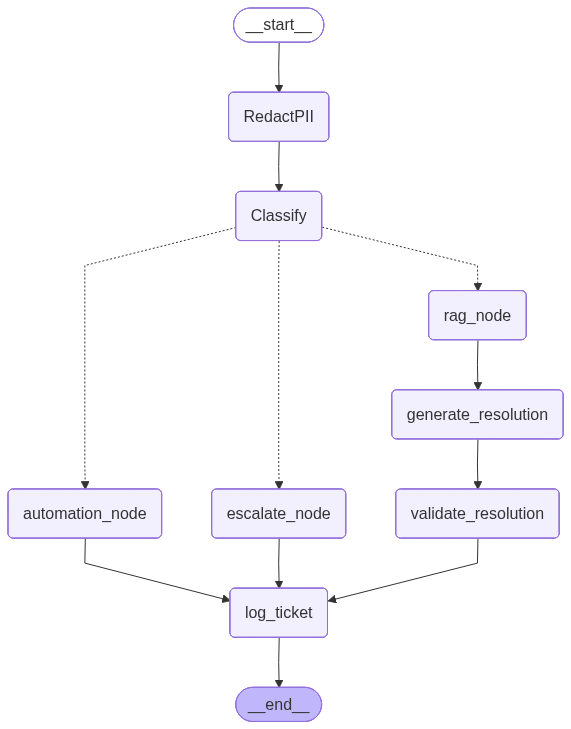

In [16]:
workflow

In [20]:
# input_state= {
#     "ticket_id":13443,
#     "original_title":"VPN disconnects",
#     "original_description":"Every time I connect to the VPN from my IP 192.168.1.50, it drops after 5 minutes. My email is john.doe@company.com .Please help!"}

# input_state = {
#     "ticket_id": "TEST-1001",
#     "original_title": "MongoDB query timing out",
#     "original_description": "Our main reporting query on the users collection is taking 15 seconds to execute and often times out. It looks like it is doing a full collection scan."
# }

# input_state = {
#     "ticket_id": "TEST-1002",
#     "original_title": "Request for Adobe Creative Cloud License",
#     "original_description": "I just transferred to the Marketing department and I need an Adobe Acrobat Pro and Photoshop license assigned to my account (j.smith@company.com). My new manager has already approved this request. Please grant the access permissions so I can start working on the new campaign assets."
# }

# input_state = {
#     "ticket_id": "TEST-1003",
#     "original_title": "Workday SSO Error",
#     "original_description": "I cannot access the Workday payroll system. I am getting a SAML integration error loop when it kicks me back to Okta. Is the system down for everyone?"
# }

# input_state = {
#     "ticket_id": "TEST-1004",
#     "original_title": "Clicked a bad link",
#     "original_description": "I think my machine is infected. I clicked a link from admin-update@paypal-fake.com. My home IP is 192.168.1.150. Please call me at 555-019-3829. - Sarah Jenkins"
# }

input_state = {
    "ticket_id": "TEST-1005",
    "original_title": "Laptop battery swelling",
    "original_description": "The trackpad on my alloted Macbook Pro in office yesterday is popping out because the battery underneath it is expanding. It is getting very hot."
}


config = {"configurable": {"thread_id": "unique_session_123"}}

# result=workflow.invoke(input_state)
# print(result)
try:
    workflow.invoke(input_state, config=config)
except Exception as e:
    print(f"Error occurred: {e}")

Redacting PII from the ticket...
{'redacted_title': 'Laptop battery swelling', 'redacted_description': 'The trackpad on my allotted MacBook Pro in the office yesterday is popping out because the battery underneath it is expanding. It is getting very hot.'}
Classifying the ticket into the appropriate category...
Determining routing for [Type: Incident | Priority: high]...
-> Decision: Standard Incident. Routing to RAG Troubleshooting.
Retrieving relevant context using Metadata Filtering...
-> Retrieved 3 historical fixes from the 'IT Support' queue.
Generating a proposed resolution for the ticket...
Error occurred: Error code: 429 - {'message': "We're experiencing high traffic right now! Please try again soon.", 'type': 'too_many_requests_error', 'param': 'queue', 'code': 'queue_exceeded'}


In [21]:
workflow.invoke(None, config=config)

Generating a proposed resolution for the ticket...
Validating the proposed resolution...
--- [NODE 6] LOGGING TICKET TEST-1005 ---
-> Ticket logged to SQLite successfully.
 Verified Fix! Promoting TEST-1005 to ChromaDB Knowledge Base...
-> Ticket promoted to ChromaDB successfully.


{'ticket_id': 'TEST-1005',
 'original_title': 'Laptop battery swelling',
 'original_description': 'The trackpad on my alloted Macbook Pro in office yesterday is popping out because the battery underneath it is expanding. It is getting very hot.',
 'redacted_title': 'Laptop battery swelling',
 'redacted_description': 'The trackpad on my allotted MacBook Pro in the office yesterday is popping out because the battery underneath it is expanding. It is getting very hot.',
 'queue': 'IT Support',
 'ticket_type': 'Incident',
 'priority': 'high',
 'confidence_score': 0.95,
 'is_repeated_issue': False,
 'retrieved_contexts': ['Subject: Problem with MacBook Air | Body: Hello Customer Support, I am contacting you regarding an unexpected crash of my MacBook Air. I suspect it could be due to overheating or a software glitch. Despite attempting to restart the device, update the software, and check the disk space, the issue continues. I would be very grateful if you could offer guidance to resolve th

In [ ]:
import sqlite3
conn = sqlite3.connect('itsm_portal.db')
cursor = conn.cursor()

cursor.execute("select * from tickets")
#cursor.execute("DELETE FROM tickets WHERE ticket_id='TKT-EMAIL-9569B9';")


#conn.commit()

rows = cursor.fetchall()
print(rows)

[('TEST-1002', '2026-04-27T18:01:19.980322', 'Technical Support', 'Incident', 'high', 'I tried to click the thing but it is completely broken today. Please fix it immediately.', 'Dear User,\n\nThank you for reporting the issue you\'re experiencing. Based on our analysis of similar incidents, we have identified a known problem affecting the ClickUp integration, which may be causing the functionality you rely on to appear unresponsive or "broken."\n\nHere is the step-by-step resolution plan:\n\n1. **Restart ClickUp Services**  \n   - Fully close and restart the ClickUp application or refresh the browser tab if using the web version.  \n   - Ensure you are logged out and back in to refresh your session.\n\n2. **Verify Integration Settings**  \n   - Navigate to your workspace settings in ClickUp and confirm that the integration is still enabled and properly configured.  \n   - Re-authenticate the integration if prompted or if connection errors are visible.\n\n3. **Clear Browser or Applicat

In [ ]:
# from chromadb.utils import embedding_functions
# import chromadb


# embedding_function = embedding_functions.SentenceTransformerEmbeddingFunction(
#     model_name="all-MiniLM-L6-v2"
# )
# client = chromadb.PersistentClient(path="./chroma_db")
# collection = client.get_or_create_collection(
#     name="ticket_history",
# )

# query = "My computer is overheating and shutting down unexpectedly"
    
# results = collection.query(
#         query_texts=[query],
#         n_results=3
#     )